# 32 — Conservation Gap Analysis

Aggregate the per-species current flows (from notebook 31) and GNN suitability
scores into a multi-species priority surface, then overlay with Swiss protected
areas to quantify conservation gaps.

**Decisions made here**:
- How to normalise raw current flow per species (max vs p99 vs rank)
- How to weight species (equal vs IUCN-weighted)
- How to combine suitability and connectivity into a priority score

**Pipeline**:
1. Load current flows + suitability from notebooks 31 / GNN output
2. Choose normalisation strategy
3. Aggregate into a multi-species priority surface
4. Overlay with WDPA protected areas
5. Quantify: what fraction of high-priority patches are protected?

### Setup

In [2]:
import config
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

with open('landscape_graph.pkl', 'rb') as f:
    G = pickle.load(f)

n_patches = G.number_of_nodes()
print(f'Graph: {n_patches:,} nodes, {G.number_of_edges():,} edges')

# Load current flows from notebook 31
current_npz = np.load('gap_analysis_output/current_flows.npz')
species_summary = pd.read_csv('gap_analysis_output/species_summary.csv')

# Load suitability scores
scores_npz = np.load('gnn_training_output/suitability_scores.npz')

SPECIES = species_summary['species'].tolist()
print(f'Species for gap analysis: {len(SPECIES)}')
print(f'Current flow arrays: {len(current_npz.files)}')

Graph: 166,464 nodes, 465,833 edges
Species for gap analysis: 12
Current flow arrays: 12


### Normalisation and aggregation

**Normalisation**: Per-species current is normalised to [0, 1] using the
99th percentile as the ceiling (values above p99 are clipped to 1).
This is more robust than max-normalisation since a single extreme
pinch-point won't compress all other values toward zero.

**Species weighting**: IUCN threat-level weights (EN=3, VU=2, NT=1).
More threatened species contribute proportionally more to the priority
surface, reflecting their greater conservation urgency.

**Priority score**: `(weighted_mean_suitability + weighted_mean_current) / 2`
— equal weight to habitat quality and connectivity.

In [3]:
# IUCN threat-level weights
IUCN_WEIGHTS = {
    'CRITICALLY_ENDANGERED': 4,
    'ENDANGERED': 3,
    'VULNERABLE': 2,
    'NEAR_THREATENED': 1,
}

all_suitability = np.zeros(n_patches, dtype=np.float64)
all_current = np.zeros(n_patches, dtype=np.float64)
total_weight = 0.0

for sp in SPECIES:
    key = sp.replace(' ', '_')

    # Suitability
    if key not in scores_npz.files:
        print(f'  WARNING: no suitability for {sp}, skipping')
        continue
    suit = scores_npz[key]

    # Current flow
    if key not in current_npz.files:
        print(f'  WARNING: no current flow for {sp}, skipping')
        continue
    current = current_npz[key]

    # Normalise current: p99-based clipping to [0, 1]
    nonzero = current[current > 0]
    if len(nonzero) == 0:
        print(f'  WARNING: {sp} has zero current everywhere, skipping')
        continue
    p99 = np.percentile(nonzero, 99)
    if p99 > 0:
        current_norm = np.clip(current / p99, 0, 1)
    else:
        current_norm = np.zeros_like(current)

    # Get IUCN weight for this species
    cat = species_summary[species_summary['species'] == sp]['iucn_category'].values[0]
    w = IUCN_WEIGHTS.get(cat, 1)

    all_suitability += suit * w
    all_current += current_norm * w
    total_weight += w
    print(f'  {sp} [{cat[:2]}] weight={w}')

# Weighted average across species
mean_suitability = all_suitability / total_weight
mean_current = all_current / total_weight

# Combined priority score
priority_score = (mean_suitability + mean_current) / 2

print(f'\nSpecies included: {int(total_weight)} weight-units from {len(SPECIES)} species')
print(f'Mean suitability: {mean_suitability.mean():.4f} (max {mean_suitability.max():.4f})')
print(f'Mean current:     {mean_current.mean():.4f} (max {mean_current.max():.4f})')
print(f'Priority score:   {priority_score.mean():.4f} (max {priority_score.max():.4f})')

  Baldellia ranunculoides [NE] weight=1
  Eryngium alpinum [NE] weight=1
  Fraxinus excelsior [NE] weight=1
  Frullania jackii [VU] weight=2
  Galanthus nivalis [NE] weight=1
  Gentiana pannonica [NE] weight=1
  Jacobaea uniflora [NE] weight=1
  Poa laxa [EN] weight=3
  Poterium dodecandrum [NE] weight=1
  Pulsatilla vulgaris [NE] weight=1
  Riccia breidleri [VU] weight=2
  Trifolium saxatile [NE] weight=1

Species included: 16 weight-units from 12 species
Mean suitability: 0.0763 (max 0.6832)
Mean current:     0.0419 (max 0.9185)
Priority score:   0.0591 (max 0.8009)


### Overlay with protected areas

In [4]:
import geopandas as gpd
import rioxarray
from s3_utils import load_zarr
from rasterio.features import rasterize
from rasterio.transform import from_bounds

# Load protected areas
pa = gpd.read_file('protected_areas_ch.geojson')
print(f'Protected areas: {len(pa)}')
print(f'Categories: {pa["iucn_cat"].value_counts().to_dict()}')

# Load patch labels raster
patch_labels_da = load_zarr(
    config.S3_PROCESSED + '/patches/patch_labels_30m.zarr',
    name='patch_label',
)
patch_labels = patch_labels_da.values
h, w = patch_labels.shape
bounds = patch_labels_da.rio.bounds()
raster_transform = from_bounds(bounds[0], bounds[1], bounds[2], bounds[3], w, h)

# Rasterise PA polygons
pa_shapes = [(geom, 1) for geom in pa.geometry if geom is not None]
pa_mask = rasterize(
    pa_shapes, out_shape=(h, w), transform=raster_transform,
    fill=0, dtype=np.uint8
)

# Map to patch level
valid = patch_labels >= 0
patch_ids_flat = patch_labels[valid].astype(np.int64)
pa_flat = pa_mask[valid].astype(np.float64)

protected_sum = np.bincount(patch_ids_flat, weights=pa_flat, minlength=n_patches)
total_count = np.bincount(patch_ids_flat, minlength=n_patches)

frac_protected = np.zeros(n_patches)
nonzero_mask = total_count > 0
frac_protected[nonzero_mask] = protected_sum[nonzero_mask] / total_count[nonzero_mask]

protected_patches = set(np.where(frac_protected > 0.0)[0])
print(f'\nProtected patches (any overlap): {len(protected_patches):,} / {n_patches:,} '
      f'({len(protected_patches)/n_patches*100:.1f}%)')

Protected areas: 10522
Categories: {'IV': 6629, 'Not Assigned': 3302, 'Ia': 553, 'Not Reported': 37, 'VI': 1}

Protected patches (any overlap): 18,948 / 166,464 (11.4%)


### Restrict to Switzerland

In [5]:
# Load Switzerland boundary
ch_boundary = gpd.read_file('switzerland_boundary.geojson')
ch_shapes = [(geom, 1) for geom in ch_boundary.geometry if geom is not None]
ch_mask = rasterize(
    ch_shapes, out_shape=(h, w), transform=raster_transform,
    fill=0, dtype=np.uint8
)

ch_flat = ch_mask[valid].astype(np.float64)
ch_sum = np.bincount(patch_ids_flat, weights=ch_flat, minlength=n_patches)
frac_in_ch = np.zeros(n_patches)
frac_in_ch[nonzero_mask] = ch_sum[nonzero_mask] / total_count[nonzero_mask]

swiss_patches = set(np.where(frac_in_ch > 0.5)[0])
n_swiss = len(swiss_patches)
print(f'Swiss patches: {n_swiss:,} / {n_patches:,} ({n_swiss/n_patches*100:.1f}%)')

protected_patches = protected_patches & swiss_patches
print(f'Protected Swiss patches: {len(protected_patches):,} / {n_swiss:,} '
      f'({len(protected_patches)/n_swiss*100:.1f}%)')

Swiss patches: 65,298 / 166,464 (39.2%)
Protected Swiss patches: 18,695 / 65,298 (28.6%)


### Analysis 1: Protection effectiveness

Compare IUCN-weighted mean habitat suitability inside vs outside protected
areas. Ratio > 1 means PAs cover better habitat for threatened species.

In [6]:
protected_arr = np.array(list(protected_patches))
unprotected_arr = np.array(list(swiss_patches - protected_patches))

print('=== Analysis 1: Protection Effectiveness (Switzerland only) ===')
print(f'Protected patches: {len(protected_arr):,} ({len(protected_arr)/n_swiss*100:.1f}%)')
print(f'Unprotected patches: {len(unprotected_arr):,}')

print(f'\n{"Species":30s} {"IUCN":>5s} {"Suit(in)":>9s} {"Suit(out)":>10s} {"Ratio":>6s}')
print('-' * 65)

for sp in SPECIES:
    key = sp.replace(' ', '_')
    if key not in scores_npz.files:
        continue
    suit = scores_npz[key]
    cat = species_summary[species_summary['species'] == sp]['iucn_category'].values[0]
    cat_short = {'CRITICALLY_ENDANGERED': 'CR', 'ENDANGERED': 'EN',
                 'VULNERABLE': 'VU', 'NEAR_THREATENED': 'NT'}.get(cat, '?')
    s_in = suit[protected_arr].mean()
    s_out = suit[unprotected_arr].mean()
    ratio = s_in / max(s_out, 1e-8)
    print(f'{sp:30s} {cat_short:>5s} {s_in:>9.4f} {s_out:>10.4f} {ratio:>6.2f}x')

# Aggregate
s_in_all = mean_suitability[protected_arr].mean()
s_out_all = mean_suitability[unprotected_arr].mean()
print(f'{"--- MEAN ---":30s} {"":>5s} {s_in_all:>9.4f} {s_out_all:>10.4f} {s_in_all/max(s_out_all,1e-8):>6.2f}x')

=== Analysis 1: Protection Effectiveness (Switzerland only) ===
Protected patches: 18,695 (28.6%)
Unprotected patches: 46,603

Species                         IUCN  Suit(in)  Suit(out)  Ratio
-----------------------------------------------------------------
Baldellia ranunculoides           NT    0.0792     0.1019   0.78x
Eryngium alpinum                  NT    0.1866     0.0985   1.89x
Fraxinus excelsior                NT    0.1651     0.1078   1.53x
Frullania jackii                  VU    0.1369     0.0806   1.70x
Galanthus nivalis                 NT    0.1774     0.1578   1.12x
Gentiana pannonica                NT    0.1419     0.1142   1.24x
Jacobaea uniflora                 NT    0.0519     0.0487   1.07x
Poa laxa                          EN    0.1152     0.1047   1.10x
Poterium dodecandrum              NT    0.0375     0.0289   1.30x
Pulsatilla vulgaris               NT    0.1193     0.1314   0.91x
Riccia breidleri                  VU    0.0375     0.0472   0.79x
Trifolium saxati

### Analysis 2: Expansion priorities

High-connectivity patches that are currently unprotected = priority
candidates for new reserves.

In [7]:
print('=== Analysis 2: Expansion Priorities (Switzerland only) ===')

swiss_arr = np.array(list(swiss_patches))
swiss_current = mean_current[swiss_arr]

# Top 10% connectivity
p90_current = np.percentile(swiss_current[swiss_current > 0], 90)
high_connectivity = set(np.where(mean_current >= p90_current)[0]) & swiss_patches
hc_protected = high_connectivity & protected_patches
hc_unprotected = high_connectivity - protected_patches

print(f'High-connectivity patches (top 10%): {len(high_connectivity):,}')
print(f'  Already protected: {len(hc_protected):,} ({len(hc_protected)/len(high_connectivity)*100:.1f}%)')
print(f'  UNPROTECTED: {len(hc_unprotected):,} ({len(hc_unprotected)/len(high_connectivity)*100:.1f}%)')

# Top 5% — critical corridors
p95_current = np.percentile(swiss_current[swiss_current > 0], 95)
critical_corridors = set(np.where(mean_current >= p95_current)[0]) & swiss_patches
cc_unprotected = critical_corridors - protected_patches

print(f'\nCritical corridor patches (top 5%): {len(critical_corridors):,}')
print(f'  UNPROTECTED: {len(cc_unprotected):,} ({len(cc_unprotected)/len(critical_corridors)*100:.1f}%)')
print(f'\nThese {len(cc_unprotected):,} patches are the highest-priority expansion candidates.')

=== Analysis 2: Expansion Priorities (Switzerland only) ===
High-connectivity patches (top 10%): 6,493
  Already protected: 3,203 (49.3%)
  UNPROTECTED: 3,290 (50.7%)

Critical corridor patches (top 5%): 3,247
  UNPROTECTED: 1,551 (47.8%)

These 1,551 patches are the highest-priority expansion candidates.


### Visualise priority surface

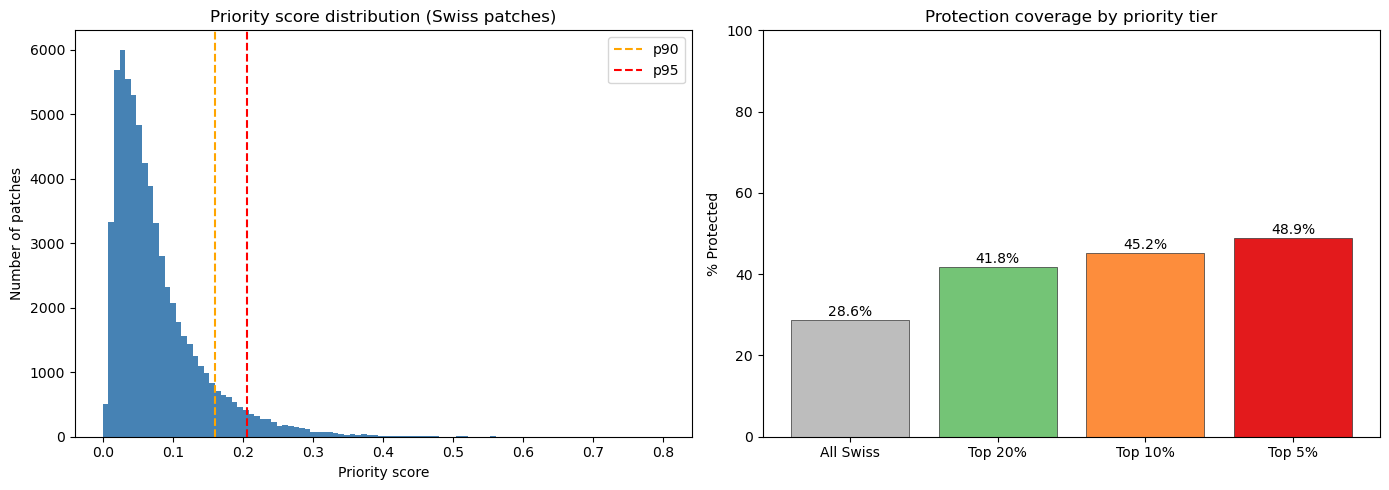

In [8]:
# Summary visualisation: priority score histogram + protection status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Priority score distribution
ax = axes[0]
swiss_priority = priority_score[swiss_arr]
ax.hist(swiss_priority[swiss_priority > 0], bins=100, color='steelblue', edgecolor='none')
ax.axvline(np.percentile(swiss_priority[swiss_priority > 0], 90), color='orange',
           linestyle='--', label='p90')
ax.axvline(np.percentile(swiss_priority[swiss_priority > 0], 95), color='red',
           linestyle='--', label='p95')
ax.set_xlabel('Priority score')
ax.set_ylabel('Number of patches')
ax.set_title('Priority score distribution (Swiss patches)')
ax.legend()

# Panel 2: Protection coverage by priority tier
ax = axes[1]
tiers = ['All Swiss', 'Top 20%', 'Top 10%', 'Top 5%']
pcts = []
for pct_thresh in [0, 80, 90, 95]:
    if pct_thresh == 0:
        tier_patches = swiss_patches
    else:
        thresh = np.percentile(swiss_priority[swiss_priority > 0], pct_thresh)
        tier_patches = set(np.where(priority_score >= thresh)[0]) & swiss_patches
    n_prot = len(tier_patches & protected_patches)
    pcts.append(n_prot / len(tier_patches) * 100 if len(tier_patches) > 0 else 0)

bars = ax.bar(tiers, pcts, color=['#bdbdbd', '#74c476', '#fd8d3c', '#e31a1c'],
              edgecolor='#333', linewidth=0.5)
ax.set_ylabel('% Protected')
ax.set_title('Protection coverage by priority tier')
ax.set_ylim(0, 100)
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{pct:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### Map 1: Full Switzerland — priority surface + protected areas

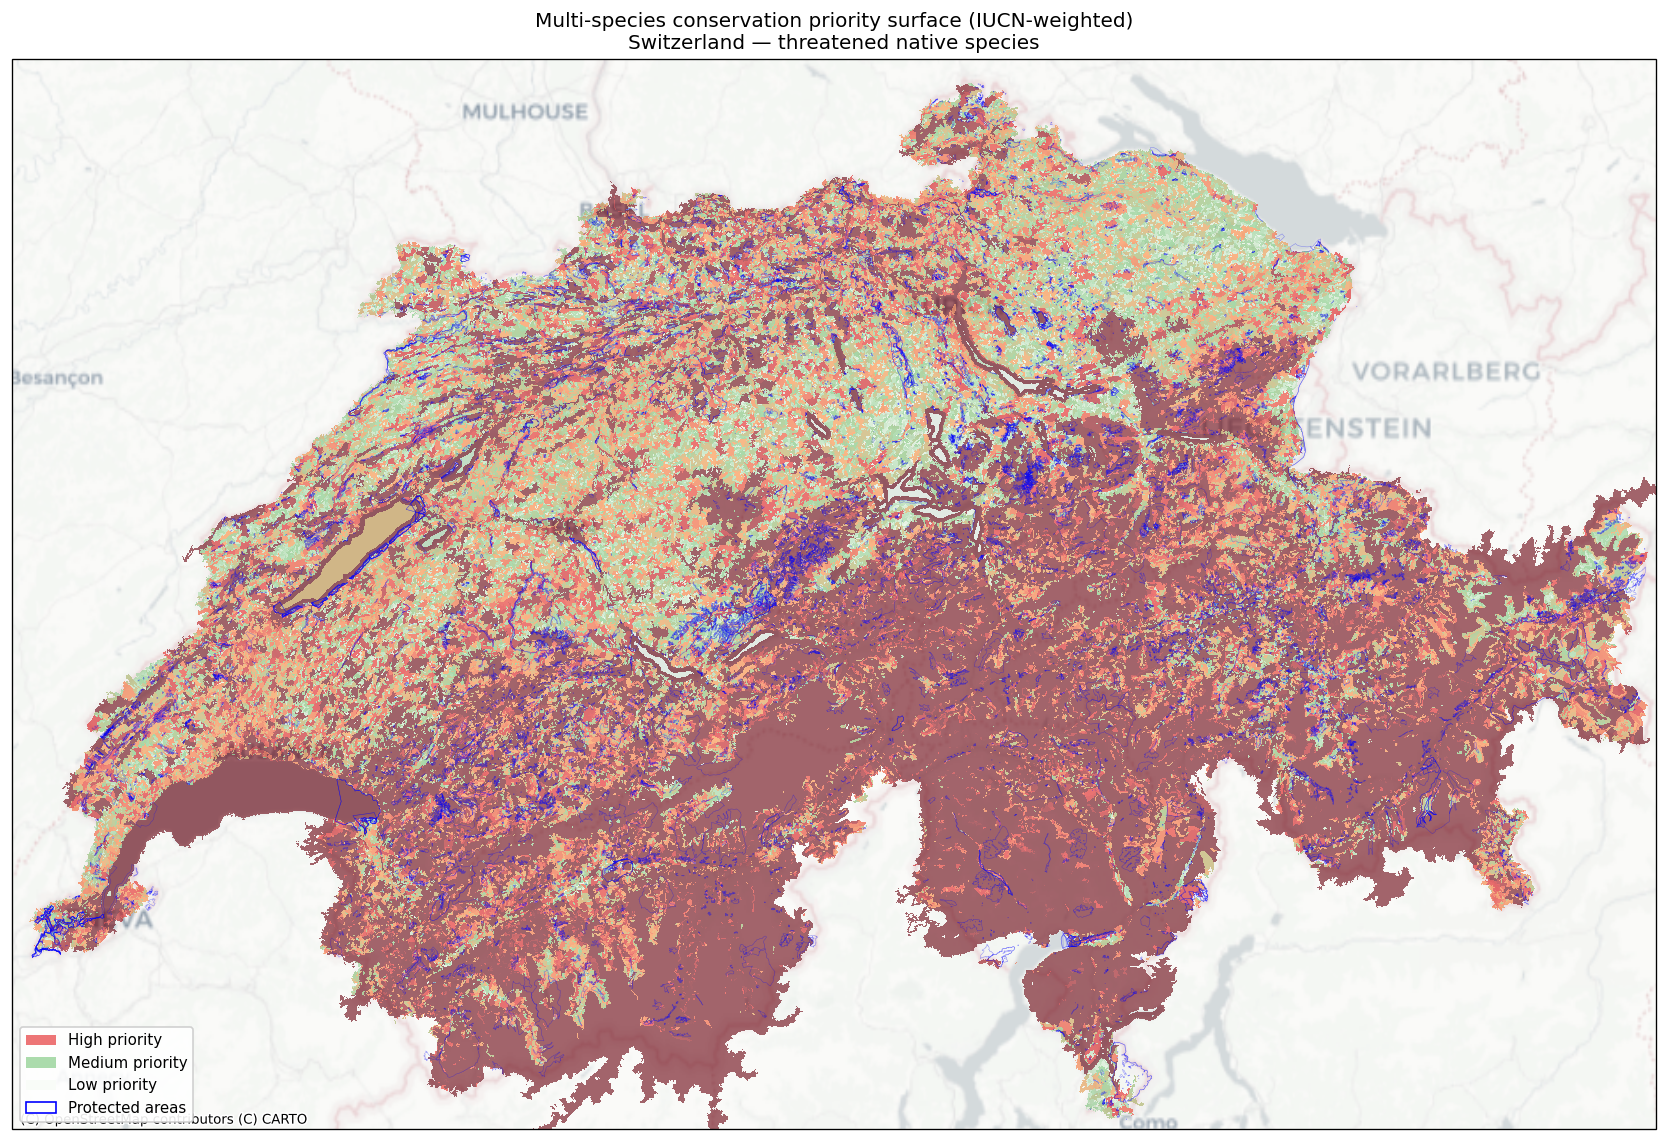

In [9]:
import numpy.ma as ma
import contextily as cx
import cartopy.crs as ccrs
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

# Switzerland extent (approx)
ch_extent = {'lon_min': 5.9, 'lon_max': 10.5, 'lat_min': 45.8, 'lat_max': 47.85}

# Map priority score onto the raster
priority_raster = np.full((h, w), np.nan, dtype=np.float32)
priority_raster[valid] = priority_score[patch_ids_flat]

# Map protection status onto the raster (1 = protected, 0 = not)
prot_raster = np.zeros((h, w), dtype=np.float32)
protected_set_arr = np.zeros(n_patches, dtype=np.float32)
for p in protected_patches:
    protected_set_arr[p] = 1.0
prot_raster[valid] = protected_set_arr[patch_ids_flat]

# Also mark Swiss boundary
swiss_set_arr = np.zeros(n_patches, dtype=np.float32)
for p in swiss_patches:
    swiss_set_arr[p] = 1.0

# Mask to Switzerland
ch_pixel_mask = np.zeros((h, w), dtype=bool)
ch_pixel_mask[valid] = swiss_set_arr[patch_ids_flat] > 0.5

priority_masked = ma.masked_where(~ch_pixel_mask | np.isnan(priority_raster), priority_raster)

# Colormaps
priority_cmap = LinearSegmentedColormap.from_list(
    'priority', ['#f7fcf5', '#74c476', '#fd8d3c', '#e31a1c', '#67000d'])

fig, ax = plt.subplots(figsize=(14, 10),
                       subplot_kw={'projection': ccrs.PlateCarree()},
                       dpi=120)
ax.set_extent([ch_extent['lon_min'], ch_extent['lon_max'],
               ch_extent['lat_min'], ch_extent['lat_max']])

cx.add_basemap(ax, crs=ccrs.PlateCarree(),
               source=cx.providers.CartoDB.Positron, zoom=8)

extent = [bounds[0], bounds[2], bounds[1], bounds[3]]

# Priority surface
p95_val = np.percentile(priority_score[priority_score > 0], 95)
ax.imshow(priority_masked, cmap=priority_cmap, vmin=0, vmax=p95_val,
          alpha=0.6, extent=extent, origin='upper',
          interpolation='nearest', transform=ccrs.PlateCarree())

# Protected area outlines
pa.boundary.plot(ax=ax, color='blue', linewidth=0.3, alpha=0.4,
                 transform=ccrs.PlateCarree())

legend_elements = [
    Patch(facecolor='#e31a1c', alpha=0.6, label='High priority'),
    Patch(facecolor='#74c476', alpha=0.6, label='Medium priority'),
    Patch(facecolor='#f7fcf5', alpha=0.6, label='Low priority'),
    Patch(facecolor='none', edgecolor='blue', linewidth=1, label='Protected areas'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=9, framealpha=0.9)
ax.set_title('Multi-species conservation priority surface (IUCN-weighted)\n'
             'Switzerland — threatened native species', fontsize=12)
plt.tight_layout()
plt.show()

### Map 2: Emmental region — priority + expansion candidates

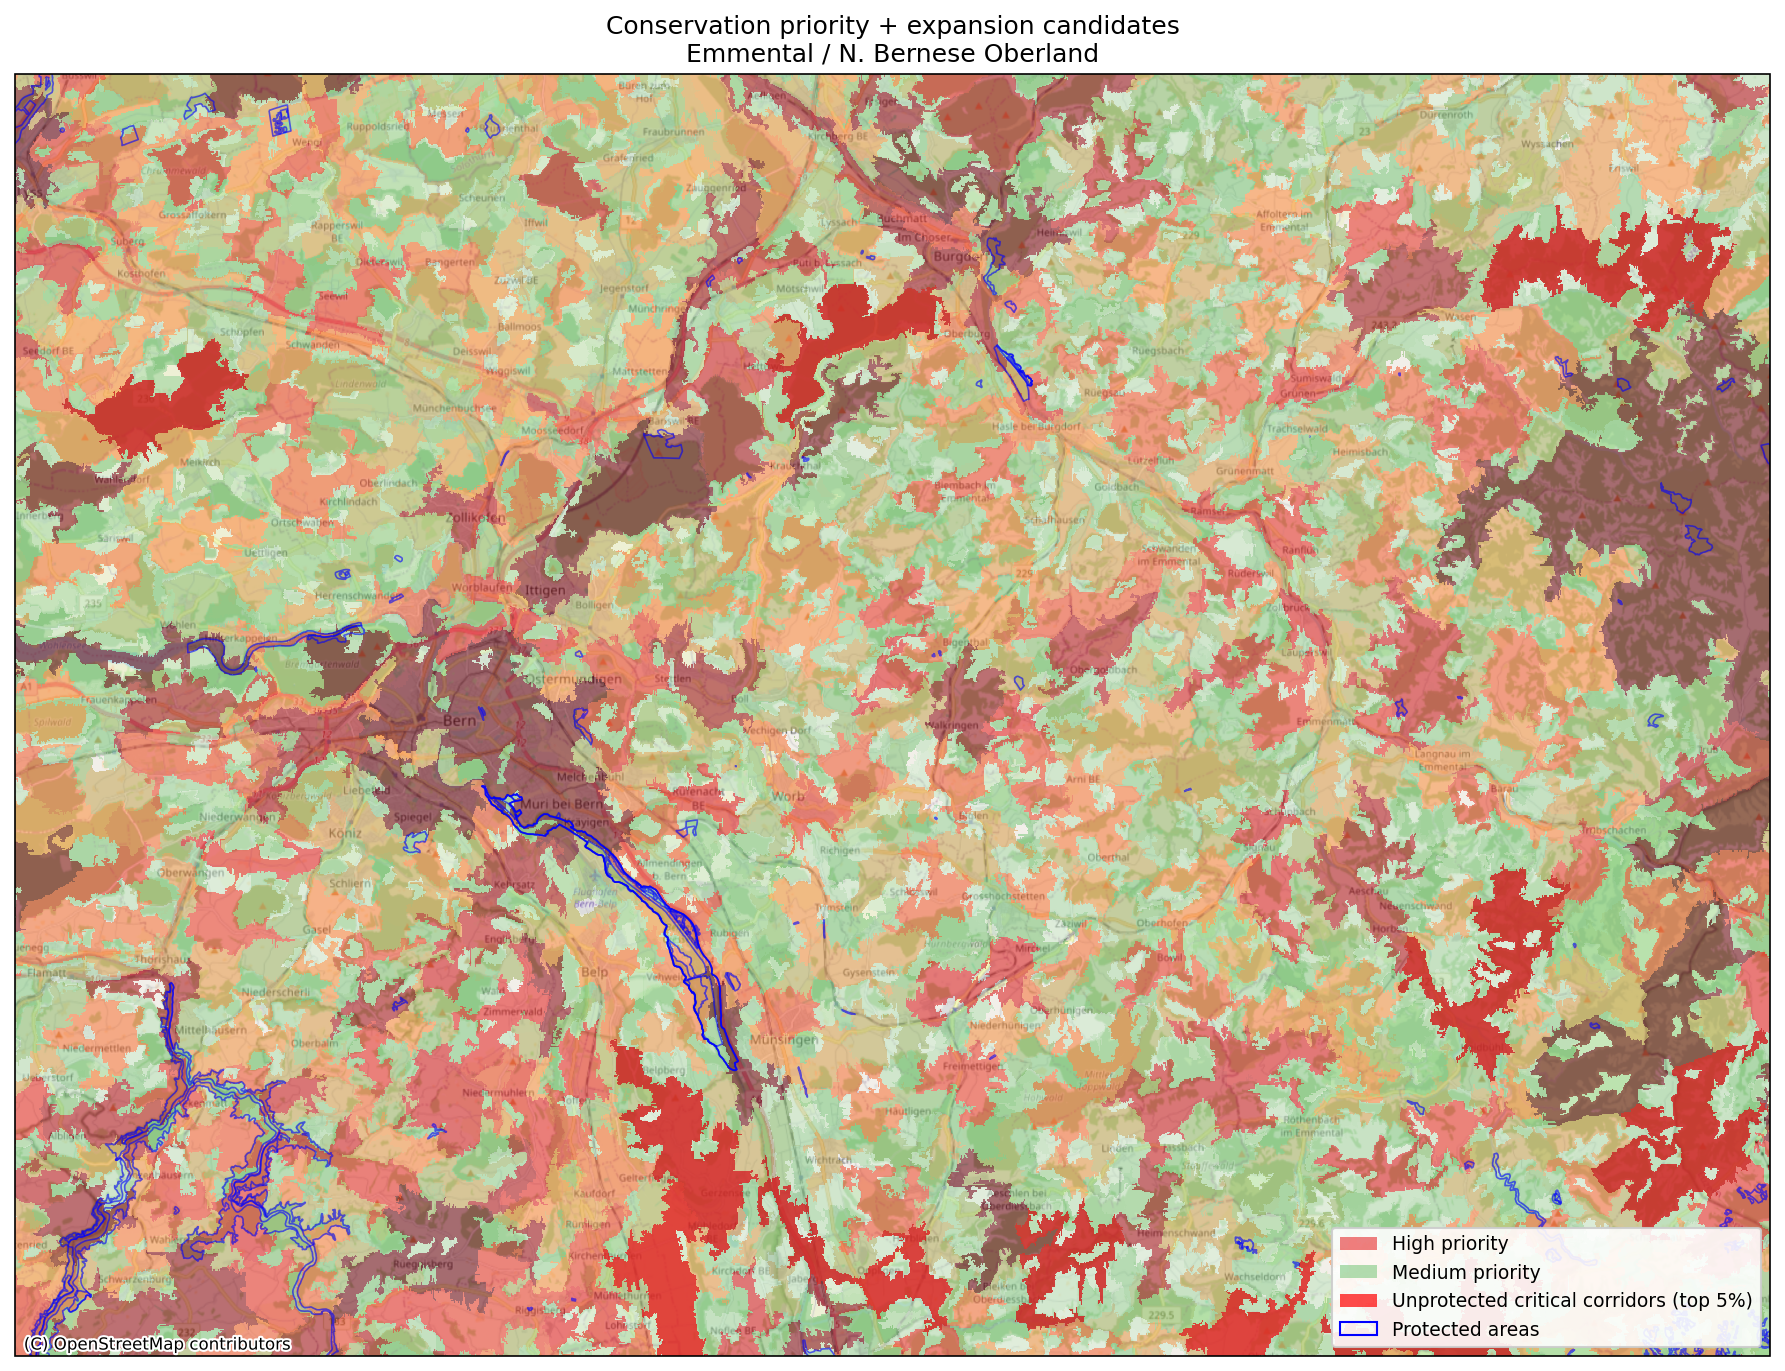

In [10]:
# Emmental / northern Bernese Oberland ROI
roi = {'lon_min': 7.3, 'lon_max': 7.9, 'lat_min': 46.8, 'lat_max': 47.1}

fig, ax = plt.subplots(figsize=(12, 10),
                       subplot_kw={'projection': ccrs.PlateCarree()},
                       dpi=150)
ax.set_extent([roi['lon_min'], roi['lon_max'],
               roi['lat_min'], roi['lat_max']])

cx.add_basemap(ax, crs=ccrs.PlateCarree(),
               source=cx.providers.OpenStreetMap.Mapnik, zoom=12)

# Clip patch labels to ROI
label_roi = patch_labels_da.sel(
    y=slice(roi['lat_max'], roi['lat_min']),
    x=slice(roi['lon_min'], roi['lon_max']),
)
labels_arr = label_roi.values
roi_valid = labels_arr >= 0
roi_extent = [roi['lon_min'], roi['lon_max'], roi['lat_min'], roi['lat_max']]

# Priority in ROI
priority_roi = np.zeros_like(labels_arr, dtype=np.float32)
priority_roi[roi_valid] = priority_score[labels_arr[roi_valid]]
priority_roi_masked = ma.masked_where(~roi_valid | (priority_roi < 0.01), priority_roi)

ax.imshow(priority_roi_masked, cmap=priority_cmap, vmin=0, vmax=p95_val,
          alpha=0.55, extent=roi_extent, origin='upper',
          interpolation='nearest', transform=ccrs.PlateCarree())

# Mark unprotected critical corridor patches (top 5%)
expansion_mask = np.zeros(n_patches, dtype=bool)
for p in cc_unprotected:
    expansion_mask[p] = True
expansion_roi = np.zeros_like(labels_arr, dtype=np.float32)
expansion_roi[roi_valid] = expansion_mask[labels_arr[roi_valid]].astype(np.float32)
expansion_roi_masked = ma.masked_where(expansion_roi < 0.5, expansion_roi)

ax.imshow(expansion_roi_masked, cmap='Reds', vmin=0, vmax=1.5,
          alpha=0.7, extent=roi_extent, origin='upper',
          interpolation='nearest', transform=ccrs.PlateCarree())

# PA outlines in ROI
pa.boundary.plot(ax=ax, color='blue', linewidth=0.8, alpha=0.6,
                 transform=ccrs.PlateCarree())

legend_elements = [
    Patch(facecolor='#e31a1c', alpha=0.55, label='High priority'),
    Patch(facecolor='#74c476', alpha=0.55, label='Medium priority'),
    Patch(facecolor='red', alpha=0.7, label='Unprotected critical corridors (top 5%)'),
    Patch(facecolor='none', edgecolor='blue', linewidth=1, label='Protected areas'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)
ax.set_title('Conservation priority + expansion candidates\n'
             'Emmental / N. Bernese Oberland', fontsize=12)
plt.tight_layout()
plt.show()